# Analisi repository di git con più stelle
Analisi delle repository più famose di git
Dipendenze:
- Matplotlib
- Pandas
- numpy

Utilizzare un venv

In [10]:
import pandas
import os
from ipywidgets import interact, widgets

datasets = []

for domain in os.listdir("../data/domains"):
    datasets.append((domain.split(".")[0], pandas.read_csv(os.path.join("../data/domains", domain))))

full_dataset = pandas.read_csv("../data/github_top_repositories.csv")

print("Lista di dataset: " + str([x[0] for x in datasets]))

Lista di dataset: ['Machine Learning', 'Deep Learning', 'Python', 'JavaScript', 'Java', 'C++', 'Go', 'Rust', 'Data Science', 'Web Development', 'Android', 'iOS', 'Blockchain', 'Cybersecurity', 'DevOps']


Esempio di come è strutturato un dataset

In [2]:
datasets[0][1]

,Repository Name,Full Name,Description,Primary Language,Stars Count,Forks Count,Watchers Count,Open Issues Count,Has Wiki,Has Pages,Has Projects,Size (KB),Created At,Updated At,Pushed At,Default Branch,Owner Login,Owner Type,License,Topics
0,tensorflow,tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,194126,75247,194126,3715,False,False,True,1288956,2015-11-07T01:19:20Z,2026-03-14T00:28:29Z,2026-03-14T01:48:00Z,master,tensorflow,Organization,Apache License 2.0,"deep-learning, deep-neural-networks, distribut..."
1,transformers,huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,157772,32464,157772,2282,True,False,True,453964,2018-10-29T13:56:00Z,2026-03-14T01:38:18Z,2026-03-13T23:15:04Z,main,huggingface,Organization,Apache License 2.0,"audio, deep-learning, deepseek, gemma, glm, ha..."
2,prompts.chat,f/prompts.chat,"f.k.a. Awesome ChatGPT Prompts. Share, discove...",HTML,152186,19999,152186,28,True,True,True,231182,2022-12-05T13:54:13Z,2026-03-14T02:08:32Z,2026-03-13T14:06:54Z,main,f,User,Creative Commons Zero v1.0 Universal,"ai, artificial-intelligence, awesome-list, cha..."
3,pytorch,pytorch/pytorch,Tensors and Dynamic neural networks in Python ...,Python,98216,27194,98216,18055,True,False,True,1273608,2016-08-13T05:26:41Z,2026-03-14T01:40:49Z,2026-03-14T02:08:49Z,main,pytorch,Organization,Other,"autograd, deep-learning, gpu, machine-learning..."
4,LLMs-from-scratch,rasbt/LLMs-from-scratch,Implement a ChatGPT-like LLM in PyTorch from s...,Jupyter Notebook,87955,13422,87955,1,False,False,False,15703,2023-07-23T18:15:57Z,2026-03-14T02:06:45Z,2026-03-07T23:05:50Z,main,rasbt,User,Other,"ai, artificial-intelligence, chatbot, chatgpt,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Machine-Learning,Jack-Cherish/Machine-Learning,:zap:机器学习实战（Python3）：kNN、决策树、贝叶斯、逻辑回归、SVM、线性回归...,Python,10250,5108,10250,7,False,False,False,1132,2017-03-25T07:32:37Z,2026-03-13T07:59:56Z,2024-07-12T11:28:35Z,master,Jack-Cherish,User,NaN,"adaboost, adaboost-algorithm, decision-tree, k..."
196,3D-Machine-Learning,timzhang642/3D-Machine-Learning,A resource repository for 3D machine learning,NaN,10144,1809,10144,20,True,False,True,24851,2017-08-12T15:20:54Z,2026-03-10T11:53:55Z,2024-07-04T19:13:09Z,master,timzhang642,User,NaN,"3d, 3d-reconstruction, constructive-solid-geom..."
197,autogluon,autogluon/autogluon,Fast and Accurate ML in 3 Lines of Code,Python,10094,1120,10094,392,False,False,True,25306,2019-07-29T18:51:24Z,2026-03-14T00:15:36Z,2026-03-10T19:01:20Z,master,autogluon,Organization,Apache License 2.0,"autogluon, automated-machine-learning, automl,..."
198,techniques,satellite-image-deep-learning/techniques,Techniques for deep learning with satellite & ...,NaN,10055,1637,10055,0,True,False,True,30166,2018-04-16T08:42:09Z,2026-03-13T05:38:12Z,2026-03-07T14:23:47Z,master,satellite-image-deep-learning,Organization,Apache License 2.0,"convolutional-neural-networks, dataset, datase..."


## Analisi del dataset

In [3]:
import matplotlib.pyplot as plt
import numpy as np

### Ambiti più popolari
Il dataset fa già una suddivisione riduttiva su gli ambiti delle repo più poplari su github, però possiamo conforntare la popolarità tra queste categorie guardando il numero di stelle

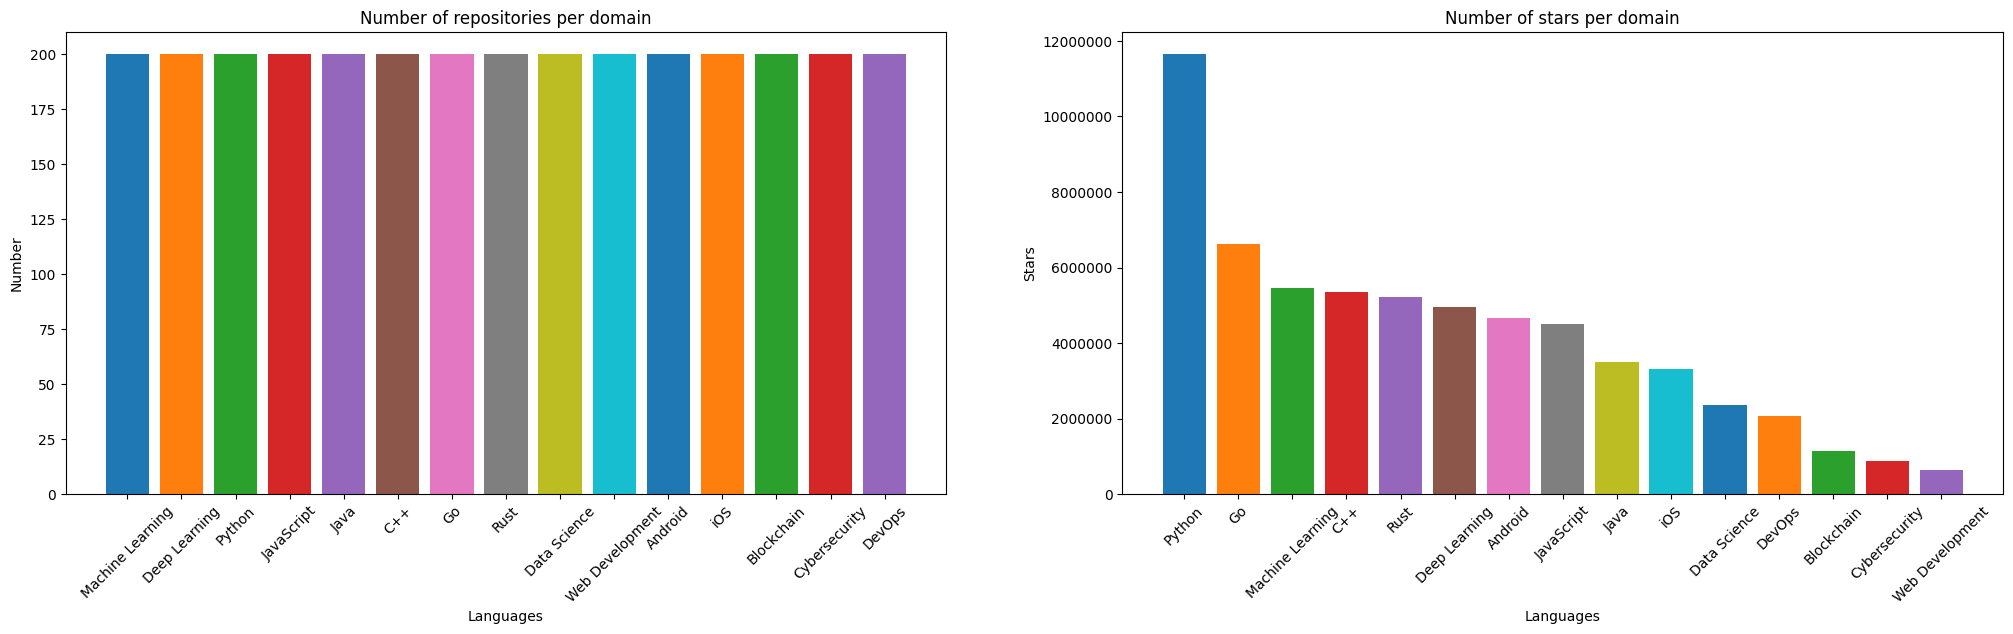

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(25, 6))

for (domain, dataset) in datasets:
    ax[0].bar(domain, len(dataset))
    ax[0].tick_params(axis='x', rotation=45)
    ax[0].set_title("Number of repositories per domain")
    ax[0].set_xlabel("Languages")
    ax[0].set_ylabel("Number")

stars = [
    (domain, df["Stars Count"].sum())
    for domain, df in datasets
]

stars = sorted(stars, key=lambda x: x[1], reverse=True)

for (domain, dataset) in stars:
    ax[1].bar(domain, dataset)
    ax[1].tick_params(axis='x', rotation=45)
    ax[1].set_title("Number of stars per domain")
    ax[1].set_xlabel("Languages")
    ax[1].set_ylabel("Stars")
    
ax[1].ticklabel_format(style='plain', axis='y')

plt.show()

Quindi possiamo notare che il dataset contiene le 200 repository con più stelle in questi domini.  
Il dominio più popolare è chiaramente Python, seguito da Go e Machine Learning

### Linguaggi più utilizzati in ogni dominio
Per ogni dominio, ogni repository ha un linguaggio predominante

Possiamo quindi trovare quali sono i linguaggi più usati in un certo dominio

In [59]:
@interact
def languages(lang = ["all", *[x[0] for x in datasets]]):
    if lang == "all" or lang == None:
        fig, ax = plt.subplots(int(len(datasets) / 3), 3, figsize=(18, 20))
        plt.tight_layout(h_pad=5.0, pad=2)
        
        for i, (domain, dataset) in enumerate(datasets):
            grouped = (
                dataset
                    .dropna(subset=["Primary Language"])
                    .groupby("Primary Language")
                    .size()
                    .sort_values(ascending=False)
            )
        
            grouped = grouped.head(10)  # top 10 languages
            row = i // 3
            col = i % 3
        
            ax[row, col].bar(grouped.index, grouped.values)
        
            ax[row, col].set_title(domain)
            ax[row, col].set_ylabel("Number of repositories")
            ax[row, col].tick_params(axis='x', rotation=45)
    else:
        (domain, dataset) = next(filter(lambda x: x[0] == lang, datasets))
        grouped = dataset.dropna(subset=["Primary Language"]).groupby("Primary Language").size().sort_values(ascending=False)
        grouped = grouped.head(10)

        plt.figure(figsize=(10, 5))
        plt.bar(grouped.index, grouped.values)
        plt.title(domain)
        plt.ylabel("Number of repositories")
        plt.tick_params(axis='x', rotation=45)


interactive(children=(Dropdown(description='lang', options=('all', 'Machine Learning', 'Deep Learning', 'Pytho…

Si può notare che in quasi tutti gli ambiti, il linguaggio più utilizzato è python. 


Però soprendentemente, anche Go, che è un linguaggio relativamente recente, è molto usato

## Dimensione della repository all'aumentare delle stelle
Forse è possibile trovare una correlazione tra numero di stelle di una repository e la sua dimensione, in quanto i progetti più longevi, e quindi con più stelle tendono ad essere più complessi

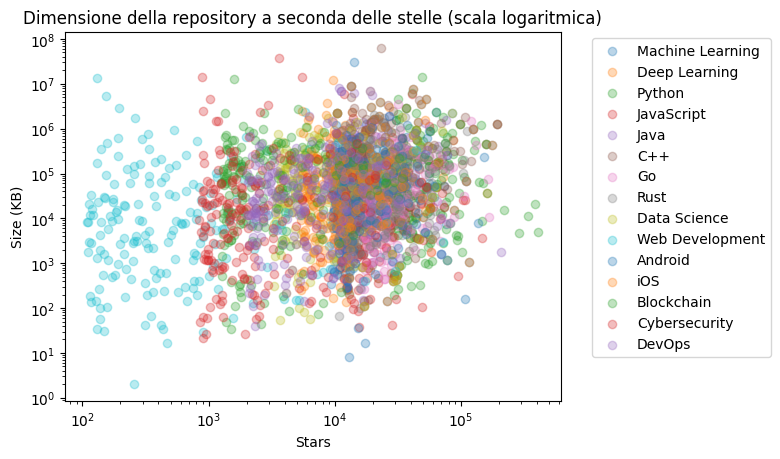

In [6]:
for (domain, dataset) in datasets:
    # threshold = dataset["Size (KB)"].quantile(0.95)
    # filtered = dataset[dataset["Size (KB)"] <= threshold]
    plt.scatter(dataset["Stars Count"], dataset["Size (KB)"], alpha=0.3, label=domain)


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Stars")
plt.ylabel("Size (KB)")
plt.title("Dimensione della repository a seconda delle stelle (scala logaritmica)")
plt.xscale("log")
plt.yscale("log")
plt.show()

Come si può notare dal grafico, in realtà non c'è una correlazione per cui il numero di stelle aumenta la dimensione della repository. Infatti le repository con più stelle hanno la dimensione vicino alla media

## Dimensione media della repository in base al dominio

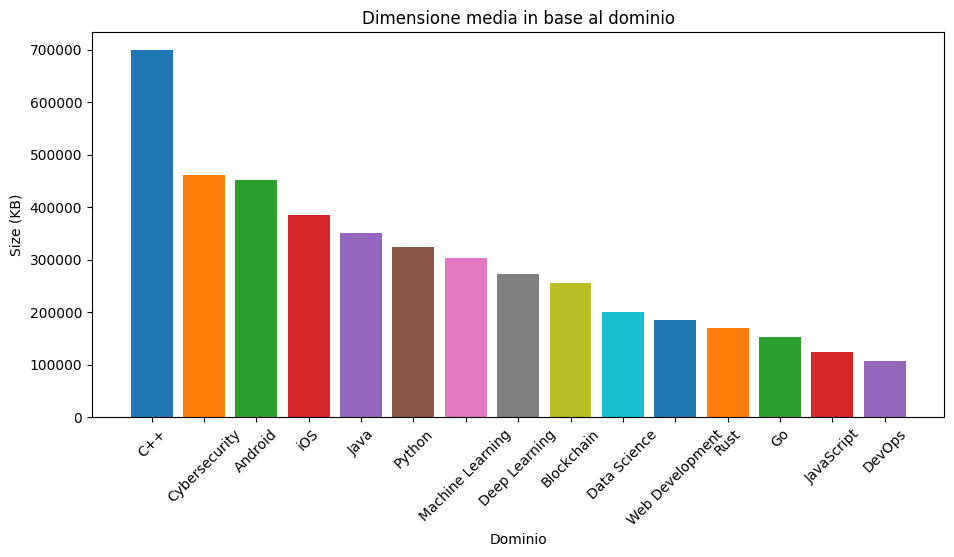

In [7]:
plt.figure(figsize=(11, 5))
for (domain, dataset) in sorted(datasets, key=lambda x: x[1]["Size (KB)"].mean(), reverse=True):
    plt.bar(domain, dataset["Size (KB)"].mean())

plt.tick_params(axis='x', rotation=45)
plt.title("Dimensione media in base al dominio")
plt.xlabel("Dominio")
plt.ylabel("Size (KB)")
plt.show()

## Rateo fork rispetto a stelle

In [24]:
@interact
def stars_to_forks(xscale = ["log", "linear"], yscale = ["log", "linear"]):
    plt.figure(figsize=(12,6))
    for (domain, dataset) in datasets:
        stars = dataset.sort_values(by="Stars Count")
        stars = stars.nlargest(100, "Stars Count")
        
        plt.scatter(stars["Stars Count"], stars["Forks Count"], label=domain)
    
    plt.xscale(xscale)
    plt.yscale(yscale)
    plt.title(f"Numero di fork rispetto alle stelle - Scala ${xscale}-${yscale}")
    
    plt.xlabel("Numero di stelle")
    plt.ylabel("Numero di fork")
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='xscale', options=('log', 'linear'), value='log'), Dropdown(descrip…

Si può notare (più facilmente utilizzando la scala logaritmica) che il grafo ha una tendenza lineare, quindi più una repository è popolare, più tende ad avere fork

In [12]:
@interact
def circle(radius=1.0, linewidth=1, color = ['red', 'blue', 'green']):
    angles = np.linspace(0,2*np.pi,100)
    fig, ax = plt.subplots()
    ax.set_aspect(1)
    ax.set_xlim(-10,10)
    ax.set_ylim(-10,10)
    ax.plot(radius*np.cos(angles), radius*np.sin(angles), linewidth = linewidth, c = color)
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='radius', max=3.0, min=-1.0), IntSlider(value=1, desc…